In [1]:
import pandas as pd

df = pd.read_csv('../data/sales_data.csv')
df.head()

,Date,Region,Category,Product,Quantity,UnitPrice,DiscountPct,TotalSales,CustomerAge,CustomerGender,PaymentMethod
0,2024-01-01,East,Groceries,Spices,11,5.80,0,63.80,NaN,Female,UPI
1,2024-01-01,West,Clothing,Shoes,5,65.05,0,325.25,45.0,Female,UPI
2,2024-01-02,North,Furniture,Bed,3,89.55,0,268.65,43.0,Male,Debit Card
3,2024-01-03,East,Groceries,Spices,8,27.18,5,206.57,59.0,Female,Net Banking
4,2024-01-03,South,Clothing,Shoes,14,39.39,15,468.74,62.0,Female,Net Banking


In [2]:
print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nData types:")
df.dtypes

Shape: (505, 11)

Column names: ['Date', 'Region', 'Category', 'Product', 'Quantity', 'UnitPrice', 'DiscountPct', 'TotalSales', 'CustomerAge', 'CustomerGender', 'PaymentMethod']

Data types:


Date                  str
Region                str
Category              str
Product               str
Quantity            int64
UnitPrice         float64
DiscountPct         int64
TotalSales        float64
CustomerAge       float64
CustomerGender        str
PaymentMethod         str
dtype: object

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            505 non-null    str    
 1   Region          505 non-null    str    
 2   Category        505 non-null    str    
 3   Product         505 non-null    str    
 4   Quantity        505 non-null    int64  
 5   UnitPrice       505 non-null    float64
 6   DiscountPct     505 non-null    int64  
 7   TotalSales      505 non-null    float64
 8   CustomerAge     487 non-null    float64
 9   CustomerGender  505 non-null    str    
 10  PaymentMethod   487 non-null    str    
dtypes: float64(3), int64(2), str(6)
memory usage: 43.5 KB


In [4]:
df.describe()

,Quantity,UnitPrice,DiscountPct,TotalSales,CustomerAge
count,505.000000,505.000000,505.000000,505.000000,487.000000
mean,7.421782,250.075604,6.118812,1662.622733,43.480493
std,4.079848,310.019052,6.476893,2555.755259,14.527791
min,1.000000,2.590000,0.000000,4.270000,18.000000
25%,4.000000,30.860000,0.000000,155.950000,30.500000
50%,7.000000,64.870000,5.000000,443.520000,44.000000
75%,11.000000,462.540000,10.000000,2073.300000,56.000000
max,14.000000,1190.030000,20.000000,15662.920000,69.000000


In [5]:
df.groupby('Region')['TotalSales'].sum().sort_values(ascending=False)

Region
South    251963.45
West     237076.81
East     181259.25
North    169324.97
Name: TotalSales, dtype: float64

In [6]:
df.groupby('Category')['Quantity'].sum().sort_values(ascending=False)

Category
Toys           864
Furniture      786
Electronics    763
Groceries      697
Clothing       638
Name: Quantity, dtype: int64

In [7]:
electronics_df = df[df['Category'] == 'Electronics']
electronics_df.head()

,Date,Region,Category,Product,Quantity,UnitPrice,DiscountPct,TotalSales,CustomerAge,CustomerGender,PaymentMethod
7,2024-01-06,East,Electronics,Headphones,5,1167.47,0,5837.35,NaN,Male,Debit Card
8,2024-01-06,East,Electronics,Tablet,13,634.86,0,8253.18,49.0,Male,UPI
15,2024-01-11,South,Electronics,Tablet,12,349.95,0,4199.40,58.0,Male,UPI
16,2024-01-12,West,Electronics,Tablet,11,1125.98,20,9908.62,42.0,Male,Debit Card
20,2024-01-15,North,Electronics,Headphones,2,690.32,10,1242.58,39.0,Male,Debit Card


In [8]:
df.groupby('Category')['TotalSales'].sum().sort_values(ascending=False)

Category
Electronics    439392.48
Furniture      327059.61
Clothing        33086.30
Toys            26750.85
Groceries       13335.24
Name: TotalSales, dtype: float64

In [9]:
import matplotlib.pyplot as plt

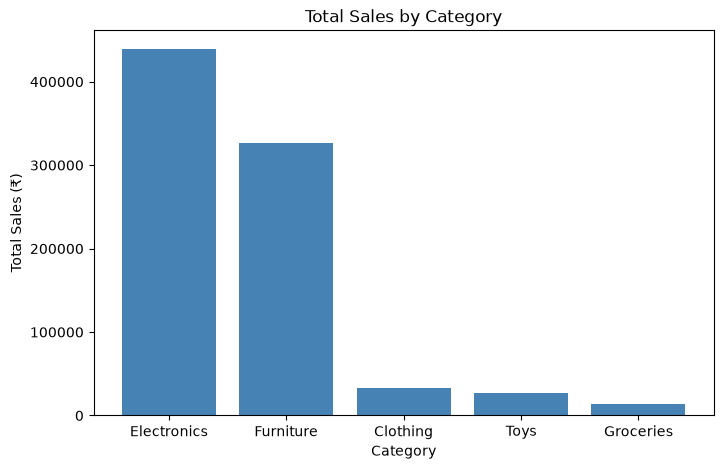

In [10]:
category_sales = df.groupby('Category')['TotalSales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(category_sales.index, category_sales.values, color='steelblue')
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales (₹)')
plt.show()

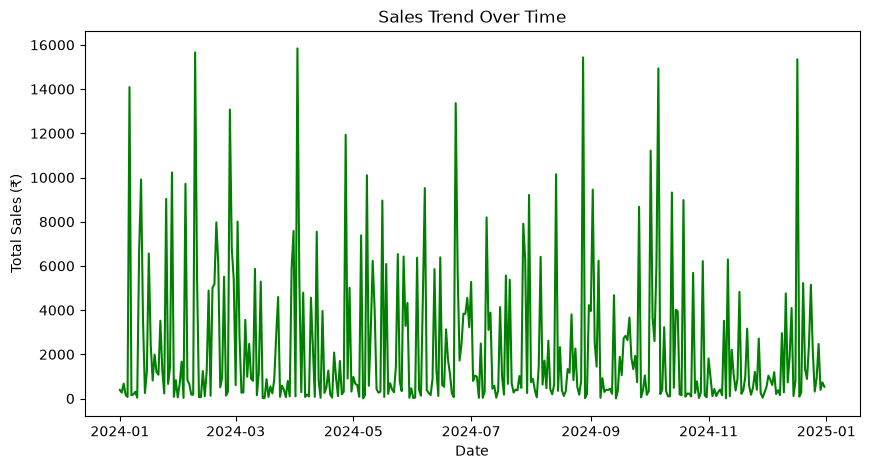

In [11]:
df['Date'] = pd.to_datetime(df['Date'])
daily_sales = df.groupby('Date')['TotalSales'].sum()

plt.figure(figsize=(10, 5))
plt.plot(daily_sales.index, daily_sales.values, color='green')
plt.title('Sales Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales (₹)')
plt.show()

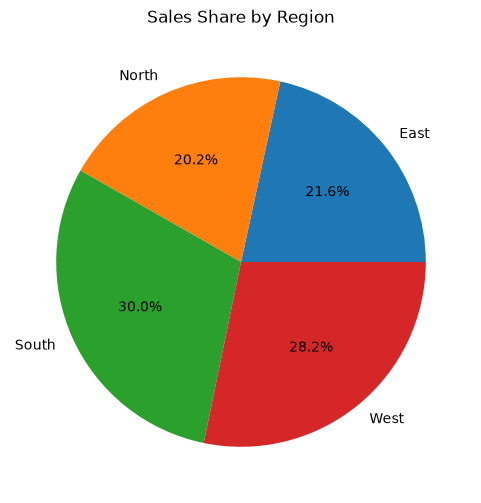

In [12]:
region_sales = df.groupby('Region')['TotalSales'].sum()

plt.figure(figsize=(6, 6))
plt.pie(region_sales.values, labels=region_sales.index, autopct='%1.1f%%')
plt.title('Sales Share by Region')
plt.show()

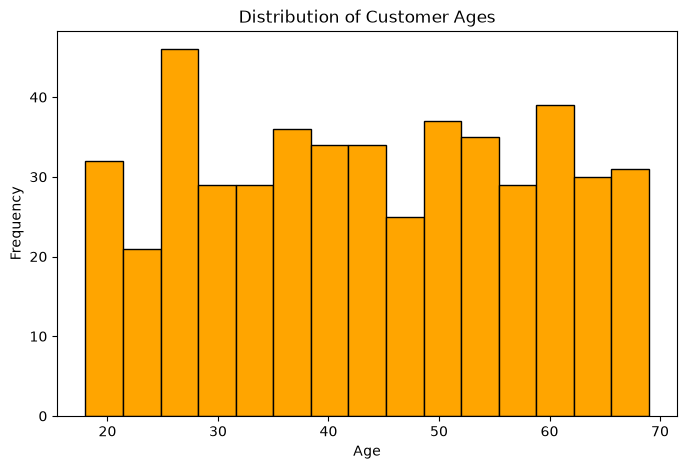

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(df['CustomerAge'].dropna(), bins=15, color='orange', edgecolor='black')
plt.title('Distribution of Customer Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

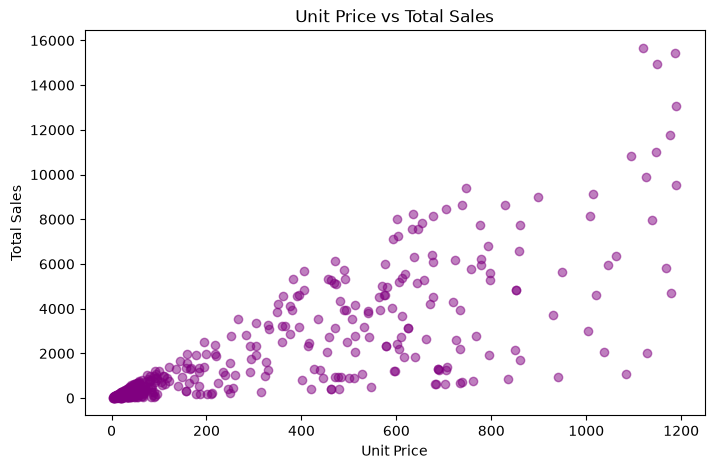

In [14]:
plt.figure(figsize=(8, 5))
plt.scatter(df['UnitPrice'], df['TotalSales'], alpha=0.5, color='purple')
plt.title('Unit Price vs Total Sales')
plt.xlabel('Unit Price')
plt.ylabel('Total Sales')
plt.show()

In [15]:
print("Duplicate rows:", df.duplicated().sum())
df[df.duplicated()]

Duplicate rows: 5


,Date,Region,Category,Product,Quantity,UnitPrice,DiscountPct,TotalSales,CustomerAge,CustomerGender,PaymentMethod
500,2024-08-10,West,Furniture,Table,2,688.30,5,1307.77,60.0,Male,Cash
501,2024-09-05,East,Furniture,Bookshelf,5,623.70,0,3118.50,28.0,Female,Cash
502,2024-02-04,East,Electronics,Headphones,6,852.32,5,4858.22,49.0,Female,Net Banking
503,2024-02-19,North,Electronics,Laptop,4,577.84,0,2311.36,49.0,Male,UPI
504,2024-12-16,East,Electronics,Headphones,1,462.54,15,393.16,63.0,Male,Debit Card


In [16]:
df = df.drop_duplicates()
print("New shape after removing duplicates:", df.shape)

New shape after removing duplicates: (500, 11)


In [17]:
# CustomerAge missing-a, andha column-oda median value-a fill pannuvom
df['CustomerAge'] = df['CustomerAge'].fillna(df['CustomerAge'].median())

# PaymentMethod missing-a, andha column-oda mode (most common value) fill pannuvom
df['PaymentMethod'] = df['PaymentMethod'].fillna(df['PaymentMethod'].mode()[0])

# verify
df.isnull().sum()

Date              0
Region            0
Category          0
Product           0
Quantity          0
UnitPrice         0
DiscountPct       0
TotalSales        0
CustomerAge       0
CustomerGender    0
PaymentMethod     0
dtype: int64

In [18]:
numeric_cols = df[['Quantity', 'UnitPrice', 'DiscountPct', 'TotalSales', 'CustomerAge']]
correlation_matrix = numeric_cols.corr()
correlation_matrix

,Quantity,UnitPrice,DiscountPct,TotalSales,CustomerAge
Quantity,1.000000,-0.061186,-0.006055,0.304107,0.051930
UnitPrice,-0.061186,1.000000,-0.043813,0.813037,0.027364
DiscountPct,-0.006055,-0.043813,1.000000,-0.067838,-0.033369
TotalSales,0.304107,0.813037,-0.067838,1.000000,0.031286
CustomerAge,0.051930,0.027364,-0.033369,0.031286,1.000000


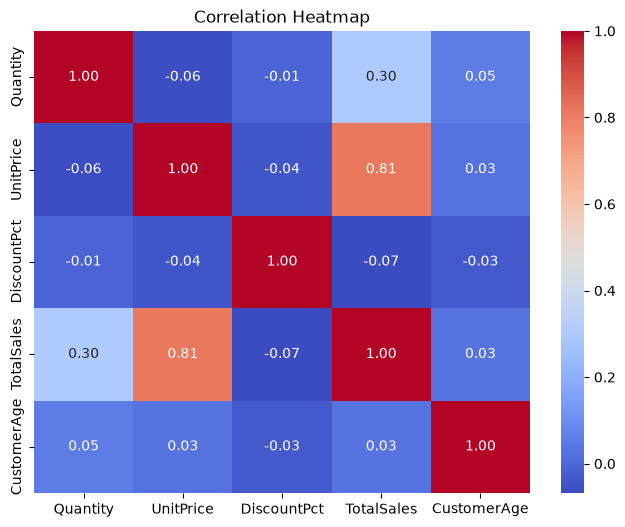

In [19]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [21]:
X = df[['Quantity', 'UnitPrice', 'DiscountPct']]
y = df['TotalSales']

print(X.shape)
print(y.shape)

(500, 3)
(500,)


In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (400, 3)
Testing set size: (100, 3)


In [23]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


In [24]:
predictions = model.predict(X_test)

# first 10 predictions vs actual values compare pannalam
comparison = pd.DataFrame({'Actual': y_test.values[:10], 'Predicted': predictions[:10]})
comparison

,Actual,Predicted
0,3341.25,2870.935361
1,939.96,2045.405889
2,168.31,-244.168756
3,110.32,-36.359957
4,222.53,76.173564
5,3943.76,3535.129449
6,11012.64,8849.774428
7,7583.88,5396.628225
8,546.73,1451.272296
9,736.48,720.668207


In [25]:
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Mean Absolute Error: {mae:.2f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error: 817.28
R² Score: 0.8271


In [26]:
from sklearn.ensemble import RandomForestRegressor

In [27]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Random Forest training complete!")

Random Forest training complete!


In [28]:
rf_predictions = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

print(f"Random Forest MAE: {rf_mae:.2f}")
print(f"Random Forest R² Score: {rf_r2:.4f}")

Random Forest MAE: 150.41
Random Forest R² Score: 0.9872


In [29]:
print("=== Model Comparison ===")
print(f"Linear Regression  -> MAE: {mae:.2f}, R²: {r2:.4f}")
print(f"Random Forest       -> MAE: {rf_mae:.2f}, R²: {rf_r2:.4f}")

=== Model Comparison ===
Linear Regression  -> MAE: 817.28, R²: 0.8271
Random Forest       -> MAE: 150.41, R²: 0.9872


In [30]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

importance_df

,Feature,Importance
1,UnitPrice,0.721842
0,Quantity,0.273265
2,DiscountPct,0.004894


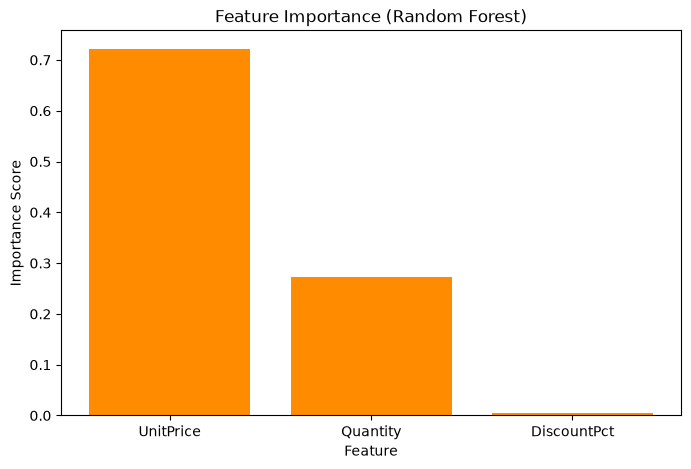

In [31]:
plt.figure(figsize=(8, 5))
plt.bar(importance_df['Feature'], importance_df['Importance'], color='darkorange')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.show()